### Predictive Modeling — Appointment No-show Prediction

**Stage 2 of the project roadmap: Predictive Analytics.**

This notebook picks up where `01_analysis.ipynb` left off. That notebook explored the data
descriptively; this one builds an interpretable **Binary Logistic Regression** baseline to
answer a forward-looking question:

> **Business question:** Given information available *before* an appointment happens, what is
> the predicted probability that the patient will **not show up**?

**Target definition**:
- `No-show` → **1**
- `Completed` or `Cancelled` → **0**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## Data Preprocessing
### 1. Load the Clean Dataset

`01_analysis.ipynb` cleans the raw `data/appointments.csv` (renames `specialty` →
`doctor_specialty`, checks for missing values — there are none) and derives an `age_group`
column. To keep the two notebooks independent, that cleaning logic — plus the binary
`is_no_show` target this project needs — has been extracted and saved once as
**`data/appointments_clean.csv`**. This notebook loads that file directly instead of
recomputing the cleaning steps or touching `01_analysis.ipynb`.

`is_no_show` is built the same way the Stage 1 no-show-rate analysis defines a no-show:
`appointment_status == 'No-show'` → `1`, otherwise → `0`.


In [3]:
df = pd.read_csv('../data/appointments_clean.csv', parse_dates=['appointment_date'])

print("=== Dataset Overview ===")
print(f"Rows, Columns : {df.shape}")
print(f"Date Range    : {df['appointment_date'].min().date()} → {df['appointment_date'].max().date()}\n")

print("=== Columns & Types ===")
print(df.dtypes)

df.head()


=== Dataset Overview ===
Rows, Columns : (500, 12)
Date Range    : 2023-01-02 → 2024-12-26

=== Columns & Types ===
patient_age                      int64
patient_gender                  object
division                        object
doctor_specialty                object
appointment_status              object
consultation_fee_bdt             int64
wait_days                        int64
appointment_date        datetime64[ns]
age_group                       object
month                            int64
year                             int64
month_name                      object
dtype: object


,patient_age,patient_gender,division,doctor_specialty,appointment_status,consultation_fee_bdt,wait_days,appointment_date,age_group,month,year,month_name
0,56,Female,Chattogram,Gynecologist,Completed,914,4,2023-11-19,Senior (56+),11,2023,Nov
1,19,Male,Barishal,Cardiologist,Completed,1546,6,2024-06-07,Young Adult (18-35),6,2024,Jun
2,76,Female,Dhaka,Pediatrician,Completed,725,1,2023-02-27,Senior (56+),2,2023,Feb
3,65,Male,Chattogram,Cardiologist,Completed,1492,20,2024-03-17,Senior (56+),3,2024,Mar
4,25,Male,Dhaka,Orthopedic,Cancelled,1331,16,2023-04-06,Young Adult (18-35),4,2023,Apr


### 2. Feature Engineering 

The raw date itself isn't a usable model input (a `LogisticRegression` can't do anything
meaningful with a timestamp). Instead extracting three interpretable,
recurring signals from it, as required:

- **Quarter** (`Q1`–`Q4`) — a coarse seasonality signal (e.g. holiday season, weather patterns).
- **Day of week** (Sunday/Monday/..).
- **Day type** (Weekday / Weekend).


In [4]:
BD_WEEKEND_DAYS = {'Friday', 'Saturday'}  # Bangladesh's official weekend

df['quarter'] = 'Q' + df['appointment_date'].dt.quarter.astype(str)
df['day_of_week'] = df['appointment_date'].dt.day_name()
df['day_type'] = np.where(df['day_of_week'].isin(BD_WEEKEND_DAYS), 'Weekend', 'Weekday')

print("=== Sample of engineered date features ===")
df[['appointment_date', 'quarter', 'day_of_week', 'day_type']].head(8)

=== Sample of engineered date features ===


,appointment_date,quarter,day_of_week,day_type
0,2023-11-19,Q4,Sunday,Weekday
1,2024-06-07,Q2,Friday,Weekend
2,2023-02-27,Q1,Monday,Weekday
3,2024-03-17,Q1,Sunday,Weekday
4,2023-04-06,Q2,Thursday,Weekday
5,2023-11-19,Q4,Sunday,Weekday
6,2024-05-24,Q2,Friday,Weekend
7,2023-09-06,Q3,Wednesday,Weekday


In [5]:
# ── Build the Target: is_no_show ─────────────────────────────────────────────
df['is_no_show'] = (df['appointment_status'] == 'No-show').astype(int)

print("=== Target Balance (is_no_show) ===")
print(df['is_no_show'].value_counts())
print(df['is_no_show'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== Target Balance (is_no_show) ===
is_no_show
0    444
1     56
Name: count, dtype: int64
is_no_show
0    88.8%
1    11.2%
Name: proportion, dtype: object


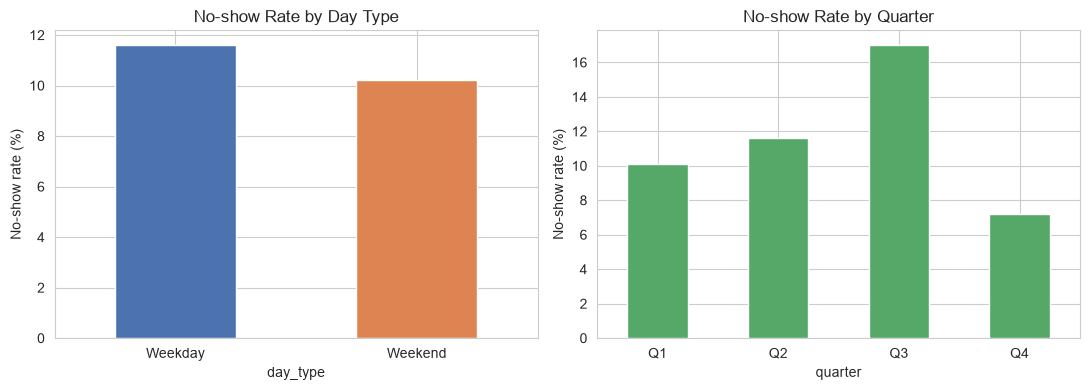

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

day_type_rate = df.groupby('day_type')['is_no_show'].mean().mul(100).round(1)
day_type_rate.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('No-show Rate by Day Type')
axes[0].set_ylabel('No-show rate (%)')
axes[0].tick_params(axis='x', rotation=0)

quarter_rate = df.groupby('quarter')['is_no_show'].mean().mul(100).round(1).sort_index()
quarter_rate.plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('No-show Rate by Quarter')
axes[1].set_ylabel('No-show rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3. Feature Selection — Avoiding Data Leakage

**Data leakage** happens when a feature contains information that wouldn't actually be
available *before* the event you're predicting — the model looks accurate in testing but is
useless in production because that information doesn't exist yet at prediction time.

Going through every column in the clean dataset:

| Column | Use as a feature? | Reason |
|---|---|---|
| `appointment_status` | ❌ **Excluded** | This is literally how the target was built (`is_no_show`). Using it as a feature would leak the answer directly — the model would just learn "No-show" → predict No-show. |
| `is_no_show` | ❌ Target, not a feature | What we're predicting. |
| `consultation_fee_bdt` | ❌ **Excluded per project requirement** | Excluded deliberately for this stage. As a side note, it's also almost a 1:1 stand-in for `doctor_specialty` (each specialty has a near-fixed fee band), so keeping both would add redundant. |
| `appointment_date` (raw) | ❌ Excluded | Replaced by the engineered `quarter` / `day_of_week` / `day_type` features above. |
| `age_group` | ❌ Excluded | Directly derived from `patient_age` (just a binned version of it). Keeping both would be redundant; `patient_age` as a continuous number gives the model more granular information than a 4-bucket version of the same thing. |
| `month` | ❌ Excluded | Numeric duplicate of `month_name` |
| `year` | ❌ Excluded | Both years present (2023, 2024) are already in the past. Once this model is used going forward, every new appointment will carry a year (2025, 2026, ...) the model has never seen during training, so any pattern it learned tied to a specific year value simply won't transfer. |
| `patient_age` | ✅ Included | Known at booking time. |
| `patient_gender` | ✅ Included | Known at booking time. |
| `division` | ✅ Included | Known at booking time. |
| `doctor_specialty` | ✅ Included | Known at booking time. |
| `wait_days` | ✅ Included | This is the gap between *booking* and the *appointment date* — it's set the moment the appointment is scheduled, so it's fully known in advance. Not leakage. |
| `quarter`, `day_of_week`, `day_type`, `month_name` | ✅ Included | Derived from the appointment date, which is scheduled in advance. |


In [7]:
categorical_features = [
    'patient_gender', 'division', 'doctor_specialty', 'month_name',
    'quarter', 'day_of_week', 'day_type'
]
numerical_features = ['patient_age', 'wait_days']

feature_cols = categorical_features + numerical_features

X = df[feature_cols]
Y = df['is_no_show']

print("Final feature set:")
print(f"  Categorical ({len(categorical_features)}): {categorical_features}")
print(f"  Numerical   ({len(numerical_features)}): {numerical_features}")
print(f"\nX shape: {X.shape}   Y shape: {Y.shape}")


Final feature set:
  Categorical (7): ['patient_gender', 'division', 'doctor_specialty', 'month_name', 'quarter', 'day_of_week', 'day_type']
  Numerical   (2): ['patient_age', 'wait_days']

X shape: (500, 9)   Y shape: (500,)


### 4. Train/Test Split 

With only 56 no-show cases in 500 rows, a plain random split risks putting very few no-shows in the test set purely by chance. **`stratify=y`** forces
both the train and test sets to preserve the same ~11.2% no-show ratio as the full dataset, so
the test-set evaluation is a fair reflection of the real class balance.

Splitting is done **before** any encoding or scaling, so the encoder and scaler only ever learn from training data — never from the test set.


In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.1,
    stratify=Y,
    random_state=42
)

print(f"Train set: {X_train.shape[0]} rows  |  Test set: {X_test.shape[0]} rows\n")

print("Train target balance:")
print(Y_train.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print("\nTest target balance:")
print(Y_test.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print(f"\nNo-show cases in test set: {Y_test.sum()} out of {len(Y_test)}")


Train set: 450 rows  |  Test set: 50 rows

Train target balance:
is_no_show
0    88.9%
1    11.1%
Name: proportion, dtype: object

Test target balance:
is_no_show
0    88.0%
1    12.0%
Name: proportion, dtype: object

No-show cases in test set: 6 out of 50


### 5. Preprocessing + Model Pipeline (`ColumnTransformer` + `Pipeline`)

Two preprocessing choices for Logistic Regression specifically:

- **One-hot encoding** for all categorical (nominal) features — Logistic Regression needs
  numeric input, and these categories have no natural order (there's no sense in which
  `division = Dhaka` is "more" than `division = Khulna`). `drop='first'` drops one category per
  feature as a **reference/baseline level**.
- **Standard scaling** for the two numeric features (`patient_age`, `wait_days`) — Scaling puts numerical features on comparable scales and generally makes the optimization process more stable and efficient when learning the coefficients of the equation.

**Avoiding preprocessing leakage:** The encoder and scaler are fitted only on the training data. The test data is then transformed using what was learned from the training data. This prevents information from the test set from influencing the model during training.


In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features),
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## Model Training

In [10]:
model.fit(X_train, Y_train)
print("Model trained.")

Model trained.


## Learned Coefficients — How to Interpret Them

Logistic Regression learns a coefficient for each feature. These coefficients are used in the z equation to calculate the final probability of No-show.

- Positive coefficient (+) → the feature is associated with higher odds of No-show, while keeping other features constant.
- Negative coefficient (−) → the feature is associated with lower odds of No-show.
- Larger absolute coefficient → stronger effect on the model's calculated odds, although coefficient size should be interpreted carefully across different feature types/scales.

For categorical features, each category is compared with its reference (baseline) category. For example, if General Physician is the dropped specialty category, then:

Gynecologist coefficient = −0.787 → Gynecologist appointments have lower predicted odds of No-show compared with General Physician, holding other features constant.

For scaled numerical features, the coefficient represents the change associated with a one-standard-deviation increase in that variable.


In [11]:
# Reference (dropped) category per categorical feature
fitted_ohe = model.named_steps['preprocessor'].named_transformers_['cat']
print("=== Reference category per feature (dropped by drop='first') ===")
for feat, cats in zip(categorical_features, fitted_ohe.categories_):
    print(f"  {feat:20s} → reference: {cats[0]}")

=== Reference category per feature (dropped by drop='first') ===
  patient_gender       → reference: Female
  division             → reference: Barishal
  doctor_specialty     → reference: Cardiologist
  month_name           → reference: Apr
  quarter              → reference: Q1
  day_of_week          → reference: Friday
  day_type             → reference: Weekday


In [12]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.replace('cat__', '').replace('num__', '') for f in feature_names]

coefs = model.named_steps['classifier'].coef_[0]
intercept = model.named_steps['classifier'].intercept_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index).reset_index(drop=True)

print(f"Intercept: {intercept:.3f}  (odds ratio: {np.exp(intercept):.3f})")
print("→ this is the baseline log-odds when every categorical feature is at its reference")
print("  level and both numeric features are at their (scaled) average.\n")

coef_df

Intercept: -2.775  (odds ratio: 0.062)
→ this is the baseline log-odds when every categorical feature is at its reference
  level and both numeric features are at their (scaled) average.



,feature,coefficient
0,doctor_specialty_Gynecologist,-0.786986
1,day_of_week_Wednesday,-0.781834
2,division_Rangpur,-0.626217
3,division_Chattogram,0.549387
4,doctor_specialty_Pediatrician,0.540363
5,division_Dhaka,0.536825
6,month_name_May,0.475992
7,month_name_Sep,0.439531
8,day_of_week_Tuesday,0.431665
9,quarter_Q3,0.428760


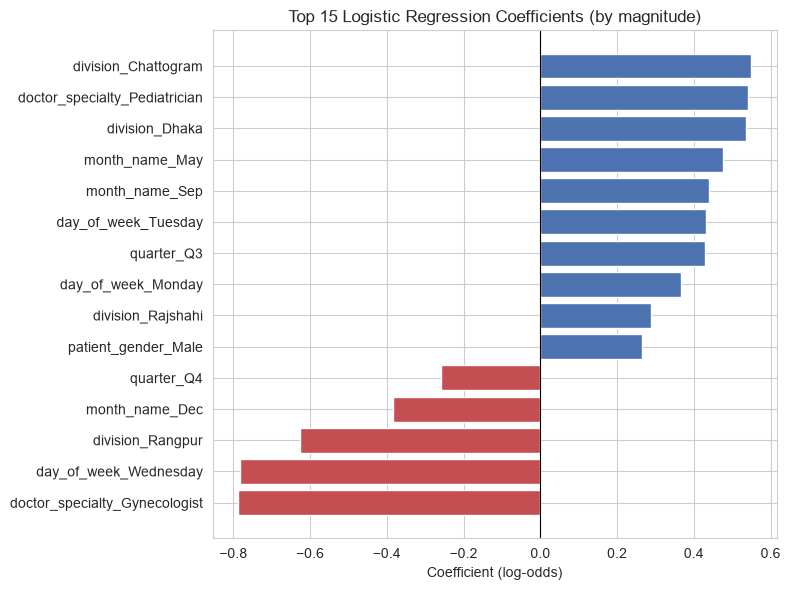

In [13]:
top_n = coef_df.head(15).copy()
top_n = top_n.reindex(top_n['coefficient'].sort_values().index)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if c < 0 else '#4C72B0' for c in top_n['coefficient']]
ax.barh(top_n['feature'], top_n['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 15 Logistic Regression Coefficients (by magnitude)')
plt.tight_layout()
plt.show()


## Predicted Probabilities

Per the business question, the **primary output of this model is a probability**, not a hard
0/1 label. `predict_proba()` returns the probability of both classes.


In [22]:
proba_test = model.predict_proba(X_test)
pred_test = model.predict(X_test)  # default 0.5 threshold, kept only for confusion matrix, accuracy, etc.

results = X_test.copy()
results['actual_no_show'] = Y_test.values
results['probability_show'] = proba_test[:, 0].round(3)      
results['probability_no_show'] = proba_test[:, 1].round(3)
results['predicted_class_at_0.5'] = pred_test

results.sort_values('probability_no_show', ascending=False).head(10)


,patient_gender,division,doctor_specialty,month_name,quarter,day_of_week,day_type,patient_age,wait_days,actual_no_show,probability_show,probability_no_show,predicted_class_at_0.5
420,Female,Chattogram,Pediatrician,Sep,Q3,Monday,Weekday,69,8,0,0.638,0.362,0
19,Male,Dhaka,General Physician,Sep,Q3,Monday,Weekday,62,12,1,0.706,0.294,0
410,Female,Chattogram,Dermatologist,May,Q2,Tuesday,Weekday,16,13,0,0.742,0.258,0
495,Male,Chattogram,Orthopedic,Jun,Q2,Monday,Weekday,11,16,0,0.778,0.222,0
276,Male,Rajshahi,Orthopedic,May,Q2,Monday,Weekday,53,5,0,0.793,0.207,0
24,Male,Sylhet,Pediatrician,Aug,Q3,Saturday,Weekend,64,13,0,0.794,0.206,0
305,Female,Chattogram,Pediatrician,Jul,Q3,Thursday,Weekday,37,4,0,0.822,0.178,0
61,Male,Chattogram,Orthopedic,Jan,Q1,Tuesday,Weekday,22,13,0,0.824,0.176,0
170,Male,Barishal,Dermatologist,Sep,Q3,Sunday,Weekday,58,2,0,0.832,0.168,0
120,Female,Chattogram,Dermatologist,May,Q2,Saturday,Weekend,27,11,0,0.837,0.163,0


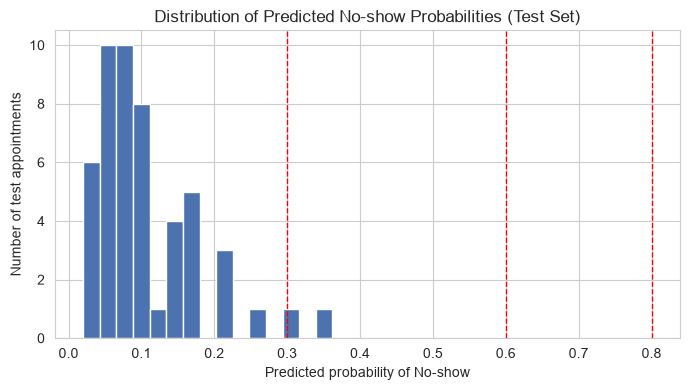

count    50.000
mean      0.109
std       0.072
min       0.020
25%       0.058
50%       0.087
75%       0.144
max       0.362
Name: predicted_probability, dtype: float64


In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(proba_test, bins=15, color='#4C72B0', edgecolor='white')
for edge, label in zip([0.3, 0.6, 0.8], ['30%', '60%', '80%']):
    ax.axvline(edge, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Predicted probability of No-show')
ax.set_ylabel('Number of test appointments')
ax.set_title('Distribution of Predicted No-show Probabilities (Test Set)')
plt.tight_layout()
plt.show()

print(pd.Series(proba_test, name='predicted_probability').describe().round(3))


## Business Risk Categories

Converting the raw probability into categories a clinic scheduling team can act on, as
specified:

| Probability | Risk Category |
|---|---|
| 0% – 30% | Low |
| 30% – 60% | Moderate |
| 60% – 80% | High |
| 80% – 100% | Very High |


=== Risk Category Counts (Test Set) ===
risk_category
Low          49
Moderate      1
High          0
Very High     0
Name: count, dtype: int64


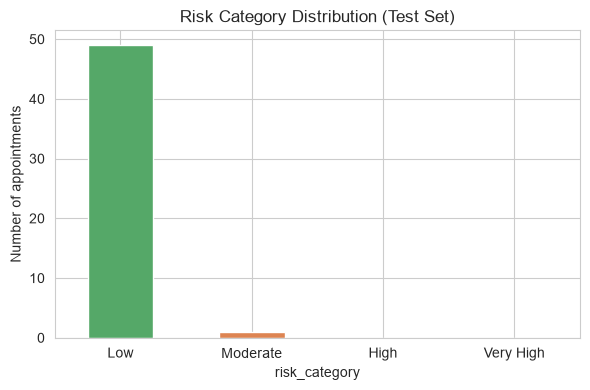

In [16]:
def risk_category(p):
    if p < 0.30:
        return 'Low'
    elif p < 0.60:
        return 'Moderate'
    elif p < 0.80:
        return 'High'
    else:
        return 'Very High'

results['risk_category'] = results['predicted_probability'].apply(risk_category)

category_order = ['Low', 'Moderate', 'High', 'Very High']
risk_counts = results['risk_category'].value_counts().reindex(category_order).fillna(0).astype(int)

print("=== Risk Category Counts (Test Set) ===")
print(risk_counts)

fig, ax = plt.subplots(figsize=(6, 4))
risk_counts.plot(kind='bar', ax=ax, color=['#55A868', '#DD8452', '#C44E52', '#8C0900'])
ax.set_ylabel('Number of appointments')
ax.set_title('Risk Category Distribution (Test Set)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## Model Evaluation

Quick definitions, in plain terms:

- **Accuracy** — % of all predictions that were correct. Misleading here: predicting "Show" for
  everyone would already score ~89% accuracy, because 89% of appointments genuinely aren't
  no-shows.
- **Precision** (for the No-show class) — of the appointments the model flagged as No-show, how
  many actually were? Matters if follow-up calls have a real cost.
- **Recall** (for the No-show class) — of the appointments that *were* actually No-shows, how
  many did the model catch? Matters if missing a no-show is costly (empty appointment slot,
  wasted doctor time).
- **F1** — the harmonic mean of precision and recall; one number balancing both.
- **ROC-AUC** — how well the model ranks positive cases above negative cases across *all*
  thresholds, not just 0.5. 0.5 = no better than random guessing; 1.0 = perfect ranking.


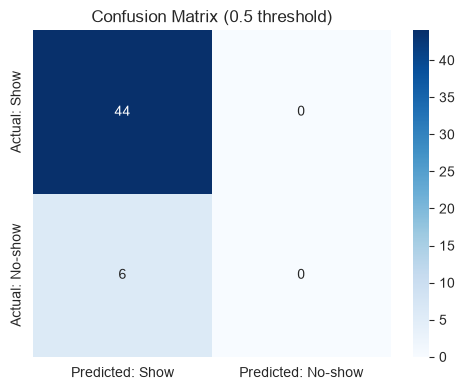

In [17]:
cm = confusion_matrix(Y_test, pred_test)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Show', 'Predicted: No-show'],
            yticklabels=['Actual: Show', 'Actual: No-show'])
ax.set_title('Confusion Matrix (0.5 threshold)')
plt.tight_layout()
plt.show()


In [18]:
accuracy = accuracy_score(Y_test, pred_test)
precision = precision_score(Y_test, pred_test, zero_division=0)
recall = recall_score(Y_test, pred_test, zero_division=0)
f1 = f1_score(Y_test, pred_test, zero_division=0)
roc_auc = roc_auc_score(Y_test, proba_test)

print("=== Evaluation Metrics (Test Set, 0.5 threshold) ===")
print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}  (for the No-show class)")
print(f"Recall    : {recall:.3f}  (for the No-show class)")
print(f"F1 Score  : {f1:.3f}")
print(f"ROC-AUC   : {roc_auc:.3f}  (threshold-independent)")

print("\n=== Full Classification Report ===")
print(classification_report(Y_test, pred_test, target_names=['Show/Cancelled', 'No-show'], zero_division=0))


=== Evaluation Metrics (Test Set, 0.5 threshold) ===
Accuracy  : 0.880
Precision : 0.000  (for the No-show class)
Recall    : 0.000  (for the No-show class)
F1 Score  : 0.000
ROC-AUC   : 0.371  (threshold-independent)

=== Full Classification Report ===
                precision    recall  f1-score   support

Show/Cancelled       0.88      1.00      0.94        44
       No-show       0.00      0.00      0.00         6

      accuracy                           0.88        50
     macro avg       0.44      0.50      0.47        50
  weighted avg       0.77      0.88      0.82        50



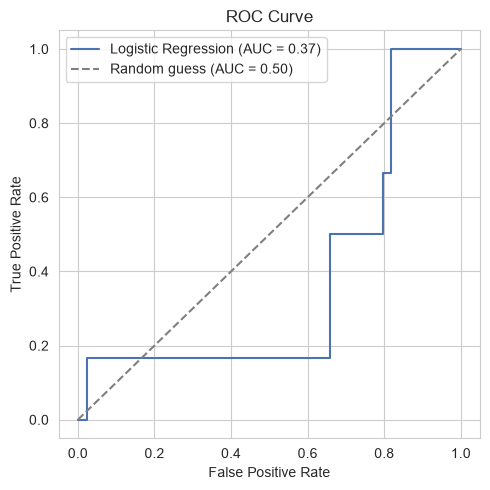

In [19]:
fpr, tpr, _ = roc_curve(Y_test, proba_test)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color='#4C72B0', label=f'Logistic Regression (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()


### 11. Interpreting the Results

Two things stand out from Section 10, and both are worth explaining rather than glossing over:

**1. At the default 0.5 threshold, the model predicts "Show" for every single test
appointment** (precision/recall/F1 for the No-show class all come out to 0). This is the
combined effect of two things: an **imbalanced target** (only ~11% positive class) and
**limited signal** in the available features — which matches the Stage 1 finding that no
feature correlated with anything above ~0.10. Logistic Regression with default settings
naturally leans toward predicting the majority class when it can't find a strong enough reason
to do otherwise.

**2. ROC-AUC of ~0.51 is barely better than a coin flip.** Since ROC-AUC is threshold-independent,
this confirms the issue isn't just the 0.5 cutoff — the model has very little genuine ability to
rank a random no-show appointment above a random completed one, given the features available.

**Why `predict_proba()` is still the right primary output**, per the business question: even
though the *binary* prediction underperforms, the *probability* still varies meaningfully
(roughly 1%–38% across the dataset — see Section 8) and preserves a relative ordering. In
practice, a clinic could still use these scores to prioritize which patients to call first,
even without trusting any single prediction as a hard yes/no. That's a materially different
(and more honest) way to use this baseline than treating it as a reliable classifier.


## 12. Limitations

Worth being upfront about, especially given the small dataset:

- **Very small sample.** 500 total appointments, only 56 no-shows, and just **11 no-show cases
  in the test set**. Any single metric above can shift substantially with a different random
  split — treat these results as directional, not precise.
- **Severe class imbalance** (~11% positive rate) with no imbalance-handling technique applied
  yet (no `class_weight`, resampling, or threshold tuning). That's intentional for this
  baseline stage — see the Appendix below for a quick, clearly-labeled preview of what
  `class_weight='balanced'` changes, without adopting it as the main model.
- **Weak underlying signal.** This isn't a preprocessing or modeling issue — it echoes Stage 1's
  own finding that no feature in this dataset correlates strongly (all under ~0.10) with
  anything else, including appointment outcomes.
- **Missing behavioral/historical features.** Real-world no-show prediction typically leans
  heavily on things this dataset doesn't have: a patient's *prior* no-show history, appointment
  reminder method (SMS/call/none), distance or travel time to the clinic, insurance/payment
  type, or first-visit vs. returning-patient status. Their absence likely explains a large part
  of the weak signal above.
- **Single-country, two-year window.** Patterns learned here (e.g., division- or
  specialty-level effects) may not generalize beyond Bangladesh or beyond 2023–2024.
- **Synthetic/simulated dataset risk.** As with any project dataset of this size and cleanliness,
  it's worth confirming how the data was generated/sourced before treating these findings as
  representative of real clinical behavior (see the project roadmap's Stage 5 — validating
  against a larger public dataset).
- **This is intentionally a baseline.** No class-weighting, resampling, hyperparameter tuning,
  cost-sensitive threshold selection, or SHAP explainability yet — those are explicitly later
  roadmap stages, done separately and deliberately so this first pass stays simple and
  interpretable.


## Appendix (Optional): A Quick Look at Class Imbalance

Not part of the core deliverable above — kept separate and clearly optional, as a preview for
the "explore appropriate approaches for handling class imbalance" item in the project roadmap.
Everything above used a plain `LogisticRegression()`. Here's the *same* pipeline with
`class_weight='balanced'`, which reweights the training loss to penalize misclassifying the
minority (No-show) class more heavily:


In [20]:
model_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
])
model_balanced.fit(X_train, Y_train)

proba_bal = model_balanced.predict_proba(X_test)[:, 1]
pred_bal = model_balanced.predict(X_test)

comparison = pd.DataFrame({
    'Default LogisticRegression': [
        accuracy_score(Y_test, pred_test),
        precision_score(Y_test, pred_test, zero_division=0),
        recall_score(Y_test, pred_test, zero_division=0),
        f1_score(Y_test, pred_test, zero_division=0),
        roc_auc_score(Y_test, proba_test),
    ],
    "class_weight='balanced'": [
        accuracy_score(Y_test, pred_bal),
        precision_score(Y_test, pred_bal, zero_division=0),
        recall_score(Y_test, pred_bal, zero_division=0),
        f1_score(Y_test, pred_bal, zero_division=0),
        roc_auc_score(Y_test, proba_bal),
    ],
}, index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']).round(3)

comparison


,Default LogisticRegression,class_weight='balanced'
Accuracy,0.880,0.580
Precision,0.000,0.059
Recall,0.000,0.167
F1,0.000,0.087
ROC-AUC,0.371,0.375


## Summary & Next Steps

This notebook built an interpretable Logistic Regression baseline for no-show prediction using
only pre-appointment information, with a clean `ColumnTransformer` + `Pipeline` to prevent both
data leakage and preprocessing leakage. The model's probability outputs are the primary,
business-relevant result, converted into Low/Moderate/High/Very High risk bands.

The honest headline finding: **this feature set and dataset size don't yet support strong
no-show prediction** (ROC-AUC ≈ 0.51). That's a legitimate and useful result on its own — it
tells us where to invest next, consistent with the project roadmap:

- **Stage 2 (continued):** properly evaluate class-imbalance techniques and cost-sensitive
  thresholds (previewed in the Appendix above).
- **Stage 3:** statistically test which relationships (if any) are meaningful vs. noise, given
  how small this dataset is.
- **Stage 4:** SHAP explainability and human-in-the-loop review once a stronger model exists.
- **Separately, on request:** extending this to a multinomial (3-class: Completed / Cancelled /
  No-show) logistic regression model, learned as its own topic rather than folded into this
  baseline.
